In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("aic_solution_policy/data/try_03.csv")
df.head()

,wall_time_iso,wall_time_s,wrench_stamp_s,abs_force_x,abs_force_y,abs_force_z,abs_torque_x,abs_torque_y,abs_torque_z,delta_force_x,...,delta_force_z,delta_torque_x,delta_torque_y,delta_torque_z,grad_force_x,grad_force_y,grad_force_z,grad_torque_x,grad_torque_y,grad_torque_z
0,2026-04-15T16:52:38.562694+00:00,1.776272e+09,59.198,0.100841,0.381862,20.359356,0.088012,-0.106520,0.007945,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2026-04-15T16:52:38.733359+00:00,1.776272e+09,59.298,0.226408,0.763283,20.372563,0.147807,-0.152223,-0.056729,0.125567,...,0.013208,0.059795,-0.045702,-0.064674,1.255674,3.814211,0.132077,0.597955,-0.457024,-0.646744
2,2026-04-15T16:52:38.899731+00:00,1.776272e+09,59.402,4.063353,-13.394765,16.869449,14.994577,1.884752,-1.412155,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,2026-04-15T16:52:39.055030+00:00,1.776272e+09,59.502,2.544840,0.684806,17.187841,0.119146,0.059446,0.028026,-1.518513,...,0.318392,-14.875431,-1.825306,1.440181,-15.185127,140.795712,3.183916,-148.754307,-18.253058,14.401812
4,2026-04-15T16:52:39.203160+00:00,1.776272e+09,59.604,2.251474,-2.444689,18.859497,-0.026990,0.044241,-0.049583,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


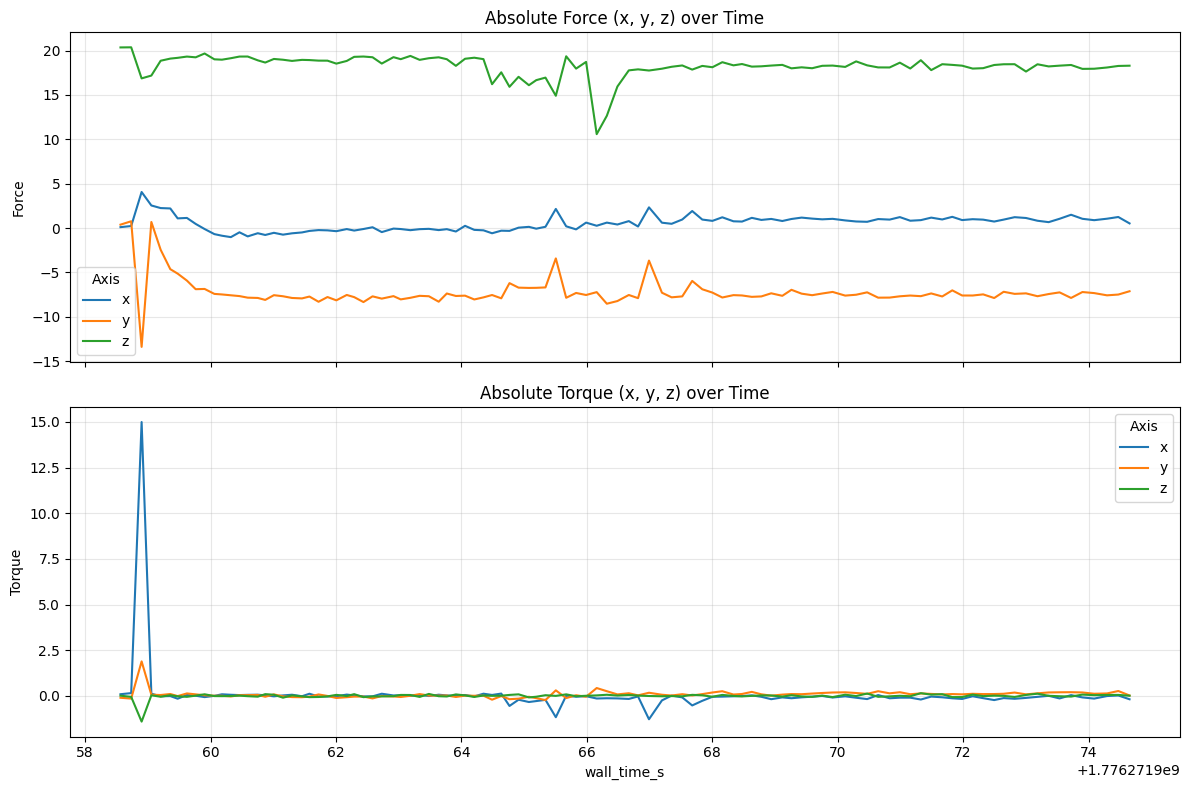

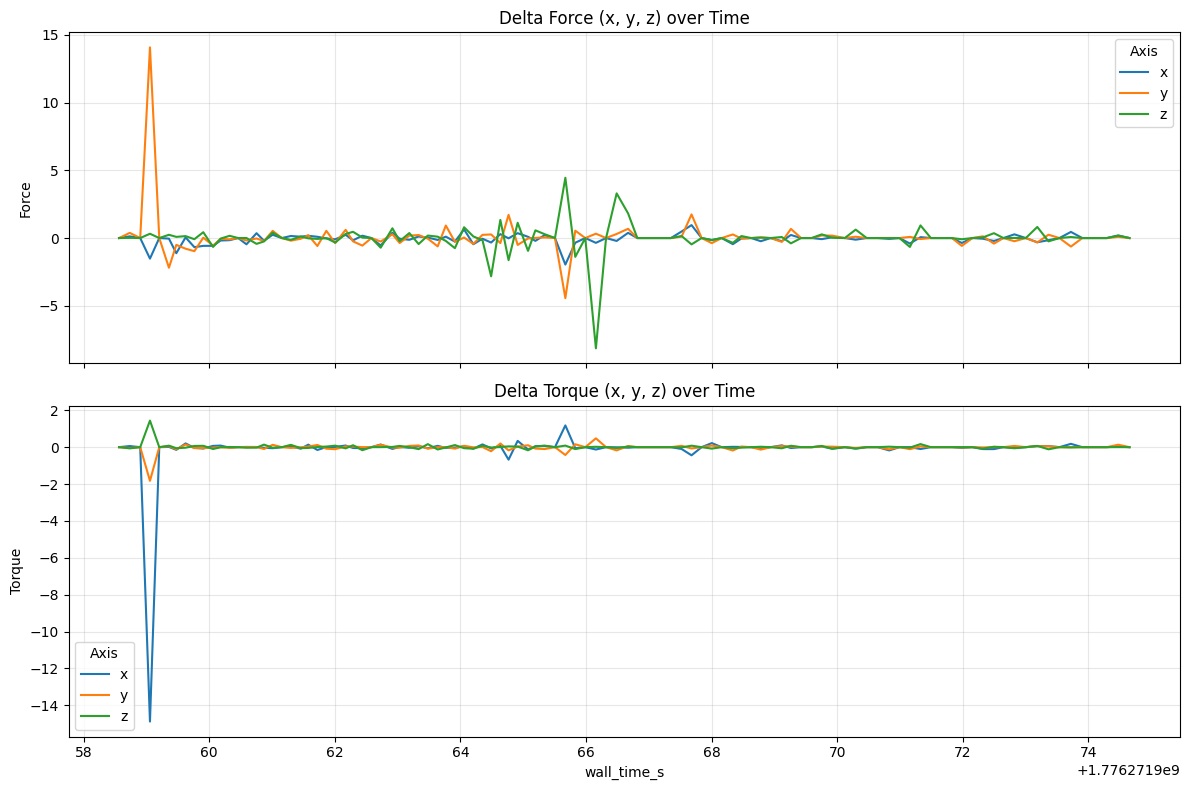

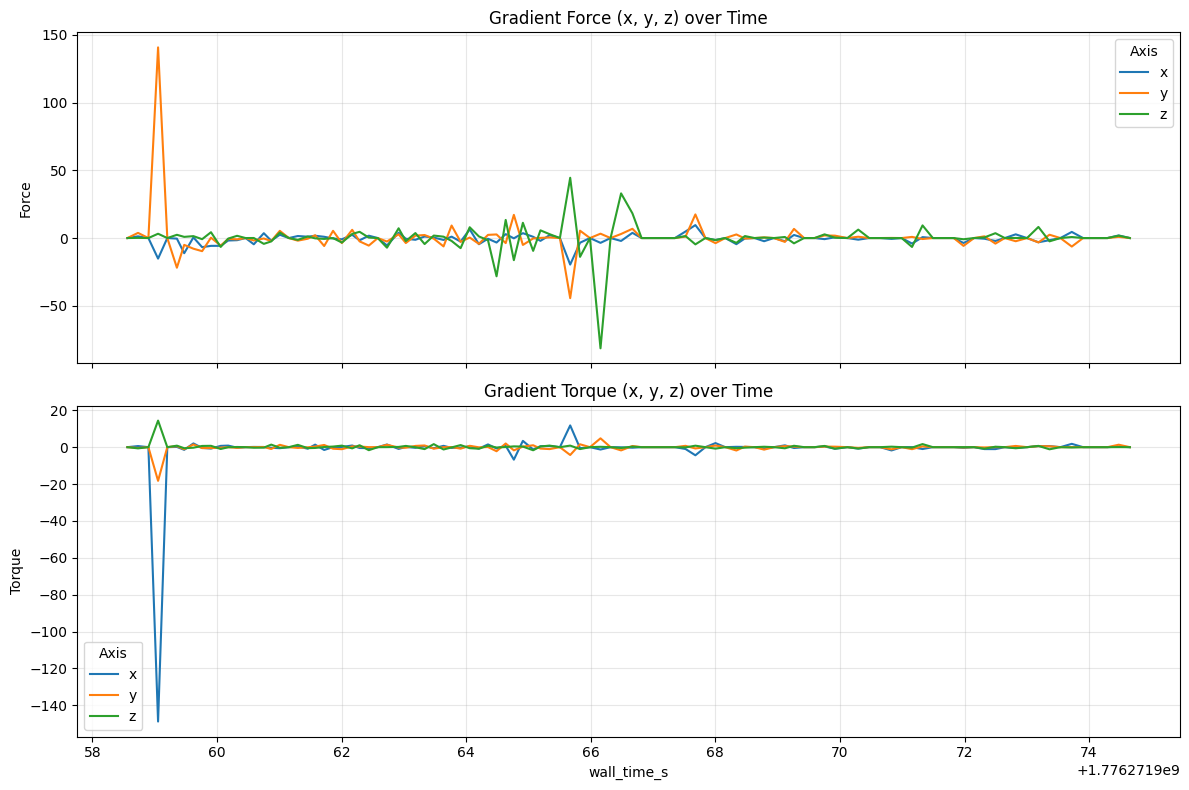

In [7]:
def plot_wrench_xyz_over_time(df, time_col="wall_time_s", figsize=(12, 8)):
    """
    Plot wrench data in three figures using df as input:
    1) Absolute force/torque over time
    2) Delta force/torque over time
    3) Gradient force/torque over time
    """
    if time_col not in df.columns:
        fallback = "wrench_stamp_s"
        if fallback in df.columns:
            time_col = fallback
        else:
            raise ValueError(
                f"Time column '{time_col}' not found and fallback '{fallback}' not available."
            )

    groups = {
        "Absolute": {
            "force": ["abs_force_x", "abs_force_y", "abs_force_z"],
            "torque": ["abs_torque_x", "abs_torque_y", "abs_torque_z"],
        },
        "Delta": {
            "force": ["delta_force_x", "delta_force_y", "delta_force_z"],
            "torque": ["delta_torque_x", "delta_torque_y", "delta_torque_z"],
        },
        "Gradient": {
            "force": ["grad_force_x", "grad_force_y", "grad_force_z"],
            "torque": ["grad_torque_x", "grad_torque_y", "grad_torque_z"],
        },
    }

    # Validate required columns up front.
    required = [
        col
        for g in groups.values()
        for cols in g.values()
        for col in cols
    ]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    axis_labels = ["x", "y", "z"]

    for group_name, cols in groups.items():
        fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)

        for i, col in enumerate(cols["force"]):
            axes[0].plot(df[time_col], df[col], label=axis_labels[i])
        axes[0].set_title(f"{group_name} Force (x, y, z) over Time")
        axes[0].set_ylabel("Force")
        axes[0].grid(True, alpha=0.3)
        axes[0].legend(title="Axis")

        for i, col in enumerate(cols["torque"]):
            axes[1].plot(df[time_col], df[col], label=axis_labels[i])
        axes[1].set_title(f"{group_name} Torque (x, y, z) over Time")
        axes[1].set_ylabel("Torque")
        axes[1].set_xlabel(time_col)
        axes[1].grid(True, alpha=0.3)
        axes[1].legend(title="Axis")

        fig.tight_layout()
        plt.show()


# Use your existing dataframe
plot_wrench_xyz_over_time(df)